# Under- and overfitting, model selection

## Preliminaries

In the first set of exercises you had to implement the training and evaluation of the linear regression and $k$-NN methods from scratch in order to practice your `numpy` skills. From this set of exercises onward, you can use the implementations provided in `scikit-learn` or other higher-level libraries. We start this set of exercises by demonstrating some of the features of `scikit-learn`.

For example, implementation of linear regression model fitting with an analytical solution for the parameters is provided by the class `sklearn.linar_model.LinearRegression`. You can train a linear regression model in the following way:

In [33]:
import numpy as np
from sklearn import datasets, linear_model

# load the diabetes dataset
diabetes = datasets.load_diabetes()

# use only one feature
X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

# split the data into training/testing sets
X_train = X[:-20]
X_test = X[-20:]

# split the targets into training/testing sets
y_train = y[:-20]
y_test = y[-20:]

# create linear regression object
model = linear_model.LinearRegression()

# train the model using the training dataset
model.fit(X_train, y_train)

LinearRegression()

Let's visualize the training dataset and the learned regression model.

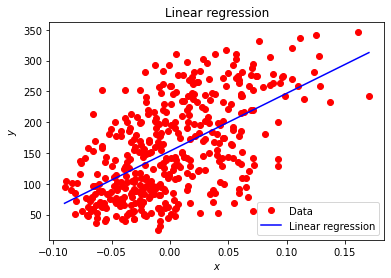

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot(X_train, y_train, 'r.', markersize=12)
X_edge = np.array([np.min(X_train, 0), np.max(X_train, 0)])
plt.plot(X_edge, model.predict(X_edge), 'b-')
plt.legend(('Data', 'Linear regression'), loc='lower right')
plt.title('Linear regression')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

Once trained, the model can be used to make predictions on the test data:

In [35]:
# Make predictions using the testing dataset
prediction = model.predict(X_test)

The next step (not shown here) is to evaluate the performance of the trained model.

Note that the `scikit-learn` interface works by first initializing an object from the class that implements the machine learning model (linear regression in this case) and then fitting the initialized model using the data in the training set. Finally, the trained (fitted) model can be used to make predictions on unseen data. In fact, all models implemented in this library follow the same *initialize-fit-predict* programming interface. For example, a $k$-NN classifier can be trained in the following way:

In [36]:
from sklearn.model_selection import train_test_split
from sklearn import datasets, neighbors

breast_cancer = datasets.load_breast_cancer()

X = breast_cancer.data
y = breast_cancer.target

# make use of the train_test_split() utility function instead
# of manually dividing the data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=40)

# initialize a 3-NN classifier
model = neighbors.KNeighborsClassifier(n_neighbors=3)

# train the model using the training dataset
model.fit(X_train, y_train)

# make predictions using the testing dataset
prediction = model.predict(X_test)

Note that the features in the breast cancer dataset have different scales (some have on average very small absolute values, and some very large), which means that the distance metric used by $k$-NN will me dominated by the features with large values. You can use any of the number of feature transformation methods implemented in `scikit-learn` to scale the features. For example, you can use the `sklearn.preprocessing.StandardScaler` method to transform all features to a have a zero mean and unit variance:

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)

The scaler has its own parameters which are the means and standard deviations of the features estimated from the training set. If you train a model with the scaled features, you will have to remember to also apply the scaling transformation every time you make a prediction on new unseen and unscaled data. This is somewhat prone to error. One option for making the code more robust is to create a processing pipeline that includes the scaling and $k$-NN models in a sequence:

In [38]:
from sklearn.pipeline import Pipeline

knn = neighbors.KNeighborsClassifier(n_neighbors=3)

model = Pipeline([
                 ("scaler", scaler),
                 ("knn", knn)
                ])

# train the model using the training dataset
model.fit(X_train, y_train)

# make predictions using the testing dataset
prediction = model.predict(X_test)


If you are curious, more information about the design of the `scikit-learn` application programming interface (API) can be found [in this paper](https://arxiv.org/pdf/1309.0238.pdf). 

## Exercises

### Bias-variance decomposition

Show that the mean squared error of the estimate of a parameter can be decomposed into an expression that includes both the bias and variance (Eq. 5.53-5.54 in "Deep learning" by Goodfellow et al.). 

<p><font color='green'>

Let $\hat{\theta}$ be an estimator for the true parameter $\theta$.  
The mean squared error (MSE) is defined as  

$$
\mathrm{MSE}(\hat{\theta}) = \mathbb{E}\!\left[(\hat{\theta} - \theta)^2\right].
$$

rewrite the error term as  

$$
\hat{\theta} - \theta = \big(\hat{\theta} - \mathbb{E}[\hat{\theta}]\big) + \big(\mathbb{E}[\hat{\theta}] - \theta\big).
$$

Substituting this gives  

$$
\mathrm{MSE}(\hat{\theta})
= \mathbb{E}\!\left[\left((\hat{\theta} - \mathbb{E}[\hat{\theta}]) + (\mathbb{E}[\hat{\theta}] - \theta)\right)^2\right].
$$



$$
\mathrm{MSE}(\hat{\theta})
= \mathbb{E}\!\left[(\hat{\theta} - \mathbb{E}[\hat{\theta}])^2\right]
+ 2(\mathbb{E}[\hat{\theta}] - \theta)\,\mathbb{E}[\hat{\theta} - \mathbb{E}[\hat{\theta}]]
+ (\mathbb{E}[\hat{\theta}] - \theta)^2.
$$

The middle term vanishes since  

$$
\mathbb{E}[\hat{\theta} - \mathbb{E}[\hat{\theta}]] = 0.
$$

So this gives 

$$
\mathrm{MSE}(\hat{\theta})
= \underbrace{\mathbb{E}\!\left[(\hat{\theta} - \mathbb{E}[\hat{\theta}])^2\right]}_{\mathrm{Var}(\hat{\theta})}
+ \underbrace{\big(\mathbb{E}[\hat{\theta}] - \theta\big)^2}_{\mathrm{Bias}(\hat{\theta})^2}.
$$

$$
\;\mathrm{MSE}(\hat{\theta}) = \mathrm{Var}(\hat{\theta}) + \mathrm{Bias}(\hat{\theta})^2\;
$$

</font><p>


### Polynomial regression

For this exercise we will be using generated data to better show the effects of the different polynomial orders.
The data is created using the make_polynomial_regression function.

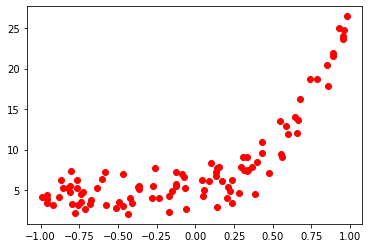

In [39]:
%matplotlib inline

def generate_dataset(n=100, degree=1, noise=1, factors=None):
    # Generates a dataset by adding random noise to a randomly
    # generated polynomial function.
    
    x = np.random.uniform(low=-1, high=1, size=n)
    
    factors = np.random.uniform(0, 10, degree+1)
    
    y = np.zeros(x.shape)
    
    for idx in range(degree+1):
        y += factors[idx] * (x ** idx)

    # add noise
    y += np.random.normal(-noise, noise, n)
    
    return x, y

# load generated data
np.random.seed(0)

X, y = generate_dataset(n=100, degree=4, noise=1.5)

plt.plot(X, y, 'r.', markersize=12)

Implement polynomial regression using the `sklearn.preprocessing.PolynomialFeatures` transformation. Using the `sklearn.grid_search.GridSearchCV` class, perform a grid search of the polynomial order hyperparameter space with cross-validation and report the performance on an independent test set.

Plot a learning curve that show the validation accuracy as a function of the polynomial order. 

<p><font color='#770a0a'>Which models have a high bias, and which models have high variance? Motivate your answer.</font><p>
    
Repeat this experiment, this time using the diabetes dataset instead of the generated data.

Best degree found: 2
Test accuracy: 0.8666666666666667


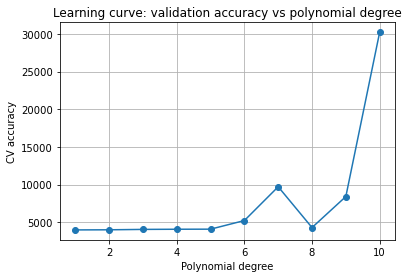

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


# fix random seed for reproducibility
np.random.seed(0)

# generate dataset
X, y = generate_dataset(n=100, degree=4, noise=1.5)
X = X.reshape(-1, 1)  # sklearn expects 2D input

# Accuracy is the asked for measure, thus classification problem:
# convert regression target to binary classification (median split)
# 1 if above median progression, 0 otherwise
y = (y > np.median(y)).astype(int)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# create the pipeline
model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),  
    ('logreg', LogisticRegression(max_iter=10000))
])

# set up the grid search

param_grid = {'poly__degree': np.arange(1, 11)}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)


print("Best degree found:", grid.best_params_['poly__degree'])

# evaluate on test set
y_pred_test = grid.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print("Test accuracy:", test_acc)

# plot learning curve
degrees = param_grid['poly__degree']
cv_acc = grid.cv_results_['mean_test_score']  

plt.plot(degrees, cv_mse, marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('CV accuracy')
plt.title('Learning curve: validation accuracy vs polynomial degree')
plt.grid(True)
plt.show()


<p><font color='green'>Models with a low polynomial degree tend to have high bias because they can only capture simple relationships, leading to systematic prediction errors and underfitting. In contrast, models with a high polynomial degree tend to have high variance, since they fit the training data too closely, which can result in overfitting and poor generalization to test data.</font><p>

Best degree found: 1
Test accuracy: 0.6666666666666666


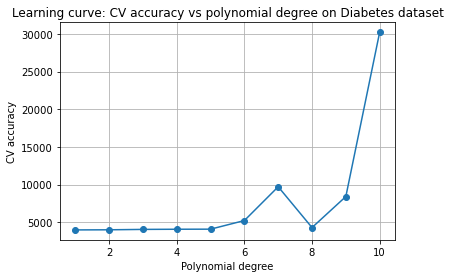

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn import datasets

diabetes = datasets.load_diabetes()

X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

# Accuracy is the asked for measure, thus classification problem:
# convert regression target to binary classification (median split)
# 1 if above median progression, 0 otherwise
y = (y > np.median(y)).astype(int)

# make use of the train_test_split() utility function instead
# of manually dividing the data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)


# create the pipeline
model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),  
    ('logreg', LogisticRegression(max_iter=10000))
])

# set up the grid search

param_grid = {'poly__degree': np.arange(1, 11)}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)


print("Best degree found:", grid.best_params_['poly__degree'])

# evaluate on test set
y_pred_test = grid.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print("Test accuracy:", test_acc)

# plot learning curve
degrees = param_grid['poly__degree']
cv_acc = grid.cv_results_['mean_test_score']  

plt.plot(degrees, cv_mse, marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('CV accuracy')
plt.title('Learning curve: CV accuracy vs polynomial degree on Diabetes dataset')
plt.grid(True)
plt.show()


### ROC curve analysis
A common method to evaluate binary classifiers is the receiver operating characteristic (ROC) curve. Similar to the week one practicals, implement a $k$-NN classifier on the breast cancer dataset, however, his time use the $k$-NN pipeline from the preliminary. Train the model for different values of $k$ and evaluate their respective performance with an ROC curve, use the `sklearn.metrics.roc_curve` function.

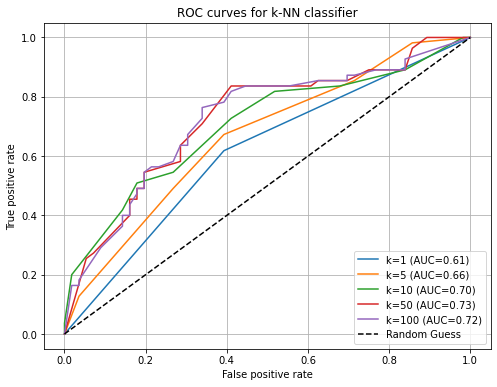

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from sklearn import datasets
import matplotlib.pyplot as plt

breast_cancer = datasets.load_breast_cancer()

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# different k values to test
k_values = [1, 5, 10, 50, 100]

plt.figure(figsize=(8, 6))

for k in k_values:
    # build pipeline (scaler + kNN)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    # train model
    model.fit(X_train, y_train)
    
    # predict probabilities (for ROC)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'k={k} (AUC={roc_auc:.2f})')

# diagonal for reference, ROC curves should lie above this 
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves for k-NN classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



<p><font color='green'>The ROC curve shows how well the k-NN classifier separates malignant vs. benign tumors of the dataset across all thresholds. The reference dashed line (diagonal) has an AUC = 0.5, which indicates random guessing. A classifier is useful if its ROC curve is above this diagonal, which is the case for all used k-values. The AUC values (~0.61–0.73) tell us that a larger k-value is better, but performance stabilizes around k=50. This is to be expected, as the classifier becomes more robust as k increases, as larger k-values smooth out noise in the dataset, until it stabilizes.</font><p>

### $F_1$ score and Dice similarity coefficient

The Dice similarity coefficient is a very popular evaluation measure for image segmentation applications. Assuming that $A$ is the ground truth segmentation of an object represented as a binary image, and $B$ is the binary output of an image segmentation method, the Dice similarity coefficient is computed as:

$\text{Dice}(A,B) = \frac{2|A\cap B|}{|A| + |B|}$

where $|\cdot|$ represents the cardinality of the objects (e.g. $|A|$ is the number of non-zero pixels in the ground truth segmentation).

For example, the Dice similarity can be computed in the following way:

0.3402777777777778


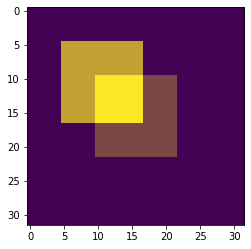

In [43]:
# generate some test objecys
A = np.zeros((32, 32))
A[10:-10, 10:-10] = 1
B = np.zeros((32, 32))
B[5:-15, 5:-15] = 1

dice = 2*np.sum(A*B)/(np.sum(A)+np.sum(B))

# display the results
plt.plot()
plt.imshow(A)
plt.imshow(B, alpha=0.7)

print(dice)

<p><font color='#770a0a'>Show that the $F_1$ score, which is the harmonic mean of precision and recall, is equivalent to the Dice similarity coefficient</font><p>

<p><font color='green'>
     
The $F_1$ score is the harmonic mean of precision and recall:
$$
F_1 = 2 \cdot \frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}.
$$

Substituting the definitions of precision and recall gives
$$
F_1
= 2 \cdot
\frac{\dfrac{TP}{TP+FP} \cdot \dfrac{TP}{TP+FN}}
{\dfrac{TP}{TP+FP} + \dfrac{TP}{TP+FN}}.
$$

The numerator simplifies to
$$
2\cdot\frac{TP^2}{(TP+FP)(TP+FN)}.
$$
The denominator simplifies to
$$
\frac{TP}{TP+FP} + \frac{TP}{TP+FN}
= \frac{TP\big((TP+FN)+(TP+FP)\big)}{(TP+FP)(TP+FN)}
= \frac{TP\,(2TP + FP + FN)}{(TP+FP)(TP+FN)}.
$$

Putting these together we obtain
$$
F_1
= \frac{2\,TP^2}{(TP+FP)(TP+FN)} \cdot
\frac{(TP+FP)(TP+FN)}{TP\,(2TP + FP + FN)}
= \frac{2TP}{2TP + FP + FN}.
$$

The Dice similarity coefficient is defined as
$$
\mathrm{Dice}(A,B) = \frac{2|A\cap B|}{|A| + |B|}.
$$
Using $|A| = TP+FN$ and $|B| = TP+FP$ yields
$$
\mathrm{Dice}(A,B)
= \frac{2TP}{(TP+FN) + (TP+FP)}
= \frac{2TP}{2TP + FP + FN}.
$$

Therefore
$$
F_1 \;=\; \mathrm{Dice}(A,B).
$$

</font><p>